# ***CT5120: Introduction to NLP***

# ***Assignment 1: Hate Speech Classification*** (Total 100 marks)
This assignment is focused on Hate Speech Classification from social media comments.

---

###  **Student Details**

Enter your

**Name: Spencer Dsheel**

**Student ID: 26246723**.

---

>  <font color="red">**Disclaimer:** This assignment may contain hate speech and offensive content, strictly for academic purposes. </font>

---
 **Deadline:** **`01:45 PM, 09th October, 2026`** (Ireland Time)

 **Submission Format:** `.ipynb`

 **Individual Assignment:** This is an individual assignment - your work must be your own.

<!-- ---

###  Academic Integrity

<font color="red">**Strictly no Generative AI.**</font> Do the assignment by yourself - write code and answers fully in your own words, without using AI tools.

<font color="red">**Note:**</font> You must **disable the AI features on Google Colab** before working on this assignment.
 Guide: [How to disable AI in Colab](https://youtu.be/qrGZv8nPh1o) -->



---

###  **In-Lab Grading — "Defend Your Work!**"

Think of this as a **mini viva** — you built it, so you should be able to talk through it.

| | |
|---|---|
|  **When** | `September 25th`, `October 2nd` & `October 9th, 2026` [12:00 PM to 02:00 PM] |
|  **What** | A short, friendly Q&A with your TAs |
|  **How** | TAs will ask you a few questions about your notebook |

>  **Pro tip:** You don't need to memorise every line. If you understand *What, How, & Why* you made each decision, you'll breeze through this.

No surprises, no trick questions - just show us it's genuinely **your work, and your understanding.**



---

###  **Task Roadmap**

Here's what you'll be building, step by step:

| # | Section | Focus |
|---|---|---|
| 1️ | **Dataset & EDA** | Pick a dataset, justify it, explore the classes (One example provided ) |
| 2️ | **Training & Evaluation** | Train a classifier, evaluate it properly |
| 3️ | **Improve It** | Tune the *same* model, prove it got better |

Each section builds on the last - so a solid dataset and clean features in Sections 1 will make Sections 2-3 much smoother.

---

###  Important

<!-- -  Only edit cells marked `# YOUR CODE HERE` or `# YOUR ANSWER HERE` — leave everything else untouched. -->
-  Run **all cells top-to-bottom** with no errors before submitting.
-  **Google Colab** is recommended to avoid dependency issues.

---

---
# **Dataset Details**

The dataset can be divided into **three parts**: **Training**, **Development (Dev)**, and **Test** sets.  

1. **Training set**  
   - Used to **train your model** (learn patterns from the data).  
   - This is the largest portion of the dataset.  

2. **Development (Dev) set**  
   - A small part of the training data that is **held out**.  
   - Used to **validate your model** while training and for **hyperparameter tuning**.  
   - Helps avoid overfitting (your model performing well on training but poorly on unseen data).  

3. **Test set**  
   - Contains **unlabeled data** (labels are hidden).
   - Used only for **final evaluation** of your model.  
   - You will generate a **prediction file** for this set and submit it.  

---

# Installing and Importing Packages

> **Note:** This setup cell is not directly graded. You may install and import any Python packages required for your experiments.  
> Commonly used libraries for this assignment may include `pandas`, `numpy`, `matplotlib`, `scikit-learn`, and relevant NLP libraries.

In [ ]:
from datasets import load_dataset_builder, load_dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression


---

# **Section 1: Dataset Selection & Exploratory Data Analysis**

### `Total = 30 marks`

Before building your classification model, select a suitable **hate-speech classification dataset** and explore its main characteristics.

> **Note:** You may use one of the example datasets provided in Task 1a, or select another appropriate publicly available dataset.

| Task | What you'll do | Marks |
|---|---|---|
| **1a** | Select and load a dataset, and prepare Train / Dev / Test splits | `5` |
| **1b** | Plot the **class distribution** using a suitable visualisation | `10` |
| **1c** | Carry out **Exploratory Data Analysis (EDA)** relevant to your dataset, such as text length, vocabulary size, common n-grams, or other informative characteristics | `5` |
| **1d** | Explain your **dataset selection** and the main findings from your EDA | `10` |

> A clear understanding of the dataset will help you make better decisions in the later modelling and evaluation sections.

---

## **1a: Dataset** (5 marks)

Select and load **one suitable hate-speech classification dataset** for this assignment.

> **Note:** You may choose **one of the example datasets listed below**, or you may use **another appropriate publicly available dataset** of your choice.

Example datasets:

1. https://huggingface.co/datasets/christinacdl/binary_hate_speech  
2. https://huggingface.co/datasets/tdavidson/hate_speech_offensive  
3. https://huggingface.co/datasets/tweets-hate-speech-detection/tweets_hate_speech_detection  
4. https://huggingface.co/datasets/badmatr11x/hate-offensive-speech  

If you choose a different dataset, it should contain:

- textual input data;
- clearly defined class labels;
- enough examples for model training and evaluation.

Use the dataset's existing **Train / Dev / Test splits** where available. If suitable splits are not provided, create them yourself.

Tutorial: [Loading a dataset from Hugging Face](https://huggingface.co/docs/datasets/load_hub)

In [7]:
 
builder = load_dataset_builder("christinacdl/binary_hate_speech")

In [8]:
builder.info.features

{'text': Value('string'), 'label': Value('string')}

In [10]:
data = load_dataset("christinacdl/binary_hate_speech")
print(data)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 31060
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 3883
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3883
    })
})


In [11]:
df_train = data['train'].to_pandas()
df_val = data['validation'].to_pandas()
df_test = data['test'].to_pandas()

In [12]:
df_train.head(5)

,text,label
0,She won't be there for long.,NOT_OFF_HATEFUL_TOXIC
1,i guess eu is gonna have to back track a littl...,NOT_OFF_HATEFUL_TOXIC
2,@user @user @user @user @user I can understand...,OFF_HATEFUL_TOXIC
3,Media Matters hates Joe diGenova - that's a re...,NOT_OFF_HATEFUL_TOXIC
4,@user @user @user @user thanks to the best b'd...,NOT_OFF_HATEFUL_TOXIC


In [15]:
label_map = {"NOT_OFF_HATEFUL_TOXIC": 0, "OFF_HATEFUL_TOXIC": 1}
for df in (df_train, df_val, df_test):
    df.dropna(subset=["text"], inplace=True)
    df["y"] = df["label"].map(label_map)

In [17]:
y_train, y_val, y_test = df_train["y"], df_val["y"], df_test["y"]

In [18]:
df_train.head(10)

,text,label,y
0,She won't be there for long.,NOT_OFF_HATEFUL_TOXIC,0
1,i guess eu is gonna have to back track a littl...,NOT_OFF_HATEFUL_TOXIC,0
2,@user @user @user @user @user I can understand...,OFF_HATEFUL_TOXIC,1
3,Media Matters hates Joe diGenova - that's a re...,NOT_OFF_HATEFUL_TOXIC,0
4,@user @user @user @user thanks to the best b'd...,NOT_OFF_HATEFUL_TOXIC,0
5,@USER Dont be that guy. Whoops. Too late. Y...,NOT_OFF_HATEFUL_TOXIC,0
6,@user the @user programme is here! the excite...,NOT_OFF_HATEFUL_TOXIC,0
7,@USER @USER Funny how so many liberals throw a...,NOT_OFF_HATEFUL_TOXIC,0
8,"ramadhan kareem, happy for all... :d #smile ...",NOT_OFF_HATEFUL_TOXIC,0
9,@USER @USER One imagines you are being sarcast...,NOT_OFF_HATEFUL_TOXIC,0


## **1b: Class Distribution** (10 marks)

In [19]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 31060 entries, 0 to 31059
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    31060 non-null  str  
 1   label   31060 non-null  str  
 2   y       31060 non-null  int64
dtypes: int64(1), str(2)
memory usage: 4.9 MB


In [20]:
df_train['label'].unique()
print(df_train.isnull().sum())

text     0
label    0
y        0
dtype: int64


In [21]:
print(df_train['label'].value_counts())
print(df_train['label'].value_counts(normalize=True)*100)

label
NOT_OFF_HATEFUL_TOXIC    15530
OFF_HATEFUL_TOXIC        15530
Name: count, dtype: int64
label
NOT_OFF_HATEFUL_TOXIC    50.0
OFF_HATEFUL_TOXIC        50.0
Name: proportion, dtype: float64


In [24]:
counts = pd.DataFrame({
    "Train": df_train["label"].value_counts(),
    "Val":   df_val["label"].value_counts(),
    "Test":  df_test["label"].value_counts(),
})
print(counts)
print("\nPercentages:\n", (counts / counts.sum() * 100).round(1))


                       Train   Val  Test
label                                   
NOT_OFF_HATEFUL_TOXIC  15530  1942  1941
OFF_HATEFUL_TOXIC      15530  1941  1942

Percentages:
                        Train   Val  Test
label                                   
NOT_OFF_HATEFUL_TOXIC   50.0  50.0  50.0
OFF_HATEFUL_TOXIC       50.0  50.0  50.0


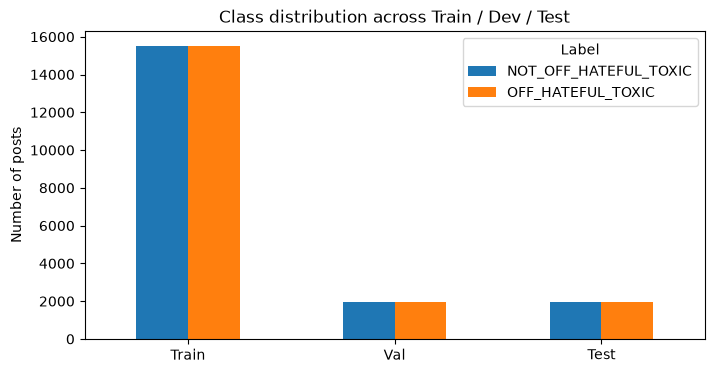

In [25]:

counts.T.plot(kind="bar", figsize=(8, 4))
plt.title("Class distribution across Train / Dev / Test")
plt.ylabel("Number of posts")
plt.xticks(rotation=0)
plt.legend(title="Label")
plt.show()

## **1c: Exploratory Data Analysis (EDA)** (5 marks)

In [32]:
df_train["n_words"] = df_train["text"].str.split().str.len()
print(df_train.groupby("label")["n_words"].describe().round(1))

                         count  mean   std  min   25%   50%   75%    max
label                                                                   
NOT_OFF_HATEFUL_TOXIC  15530.0  18.4  13.6  1.0   9.0  15.0  23.0  325.0
OFF_HATEFUL_TOXIC      15530.0  21.5  13.8  1.0  11.0  18.0  28.0  235.0


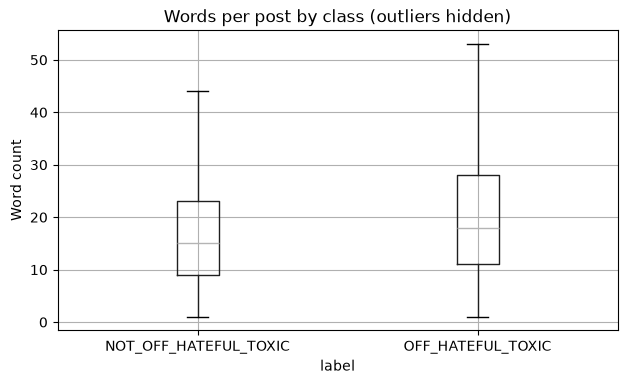

In [34]:
df_train.boxplot(column="n_words", by="label", showfliers=False, figsize=(7, 4))
plt.suptitle("")
plt.title("Words per post by class (outliers hidden)")
plt.ylabel("Word count")
plt.show()


In [35]:
countv = CountVectorizer()
countv.fit(df_train["text"])
print("Vocabulary Size:", len(countv.vocabulary_))

Vocabulary Size: 41099


In [37]:
def top_ngrams(texts, ngram=(2,2), k=10):
    vec = CountVectorizer(ngram_range=ngram, stop_words="english")
    x = vec.fit_transform(texts)
    freqs = np.asarray(x.sum(axis=0)).ravel()
    top = freqs.argsort()[::-1][:k]
    return list(zip(vec.get_feature_names_out()[top], freqs[top]))

for lab in label_map:
    print(f"\nTop bigrams - {lab}:")
    for gram, n in top_ngrams(df_train.loc[df_train["label"] == lab, "text"]):
        print(f"  {gram}: {n}")


Top bigrams - NOT_OFF_HATEFUL_TOXIC:
  user user: 6809
  https www: 336
  gun control: 303
  newline newline: 176
  http www: 126
  youtube com: 123
  https youtu: 121
  com watch: 120
  www youtube: 119
  user just: 95

Top bigrams - OFF_HATEFUL_TOXIC:
  user user: 8774
  gun control: 671
  user liberals: 147
  user bitch: 122
  user just: 121
  newline newline: 116
  user don: 114
  user fuck: 110
  user oh: 83
  don want: 76


In [38]:
patterns = {"URLs": r"http\S+", "@mentions": r"@\w+", "#hashtags": r"#\w+"}
for name, pat in patterns.items():
    pct = df_train["text"].str.contains(pat, regex=True).mean() * 100
    print(f"Posts containing {name}: {pct:.1f}%")

Posts containing URLs: 5.6%
Posts containing @mentions: 52.8%
Posts containing #hashtags: 30.6%


## **1d: Explanation** (10 marks)

**Question:** Explain your dataset selection and your Exploratory Data Analysis (EDA) process.

Your answer should cover:
- **Why you selected this dataset?**
- **The EDA process carried out in Tasks 1a to 1c**. what you looked at (class distribution, text statistics, etc.).

Your explanation should be written in your own words and should not exceed **50 words** in length.

```
# YOUR ANSWER HERE



```

---

#  **Section 2**: Feature Extraction, Model Training & Evaluation

### `Total = 40 marks`

Time to build your baseline model. In this section, you will convert the text into suitable numerical features or embeddings, train a classical machine-learning classifier, and evaluate its performance using appropriate metrics.

| Task   | What you'll do                                                                                                                                                            | Marks |
| ------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----: |
| **2a** | Perform **feature extraction** using a suitable technique |  `10` |
| **2b** | Train a suitable **classical ML baseline classifier** using the extracted features                                                                                        |  `10` |
| **2c** | **Predict and evaluate** the model using multiple appropriate evaluation metrics                                                                                          |  `10` |
| **2d** | Explain your **feature extraction method, model choice, evaluation metrics, and results**                                                                                 |  `10` |

>  Choose a feature representation and classical machine-learning model that are suitable for your dataset. Your goal here is to establish a clear and well-evaluated **baseline model**. You will improve this same model in Section 3.

---


## **2a: Feature Extraction / Text Representation** (10 marks)
Use a suitable feature extraction or text representation technique to convert the text data into numerical features that can be used by a classical machine-learning model.

* You may use an appropriate method such as: Bag-of-Words, TF-IDF, Word2Vec, FastText or another suitable feature representation method

Your implementation should clearly show how the training, validation, and test data are transformed.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer()
X_train = tf.fit_transform(df_train["text"])
X_val = tf.transform(df_val["text"])
X_test = tf.transform(df_test["text"])

print("Train:", X_train.shape, "Dev:", X_val.shape, "Test:", X_test.shape)


Train: (31060, 41099) Dev: (3883, 41099) Test: (3883, 41099)


## **2b: Classifier Model** (10 marks)
Train a suitable classical machine-learning classifier using the features produced in Task 2a.

In [40]:
basemodel = LogisticRegression(max_iter=1000, random_state=42)
basemodel.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

## **2c: Predict & Evaluate** (10 marks)
Use your trained model to make predictions on the test set and evaluate its performance using multiple suitable evaluation metrics.

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

def evaluate(model, X, y, title):
    pred = model.predict(X)
    print(f"=== {title} ===")
    print(classification_report(y, pred, target_names=list(label_map), digits=3))
    ConfusionMatrixDisplay.from_predictions(y, pred, display_labels=["Not hate", "Hate"])
    plt.title(title)
    plt.show()
    return {
        "Accuracy":         accuracy_score(y, pred),
        "Precision (hate)": precision_score(y, pred),
        "Recall (hate)":    recall_score(y, pred),
        "F1 (hate)":        f1_score(y, pred),
        "Macro-F1":         f1_score(y, pred, average="macro"),
    }


=== Baseline - Validation ===
                       precision    recall  f1-score   support

NOT_OFF_HATEFUL_TOXIC      0.772     0.740     0.756      1942
    OFF_HATEFUL_TOXIC      0.750     0.782     0.766      1941

             accuracy                          0.761      3883
            macro avg      0.761     0.761     0.761      3883
         weighted avg      0.761     0.761     0.761      3883



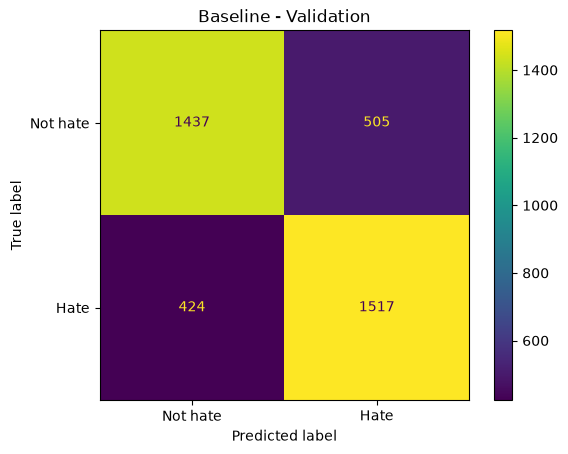

=== Baseline - Test ===
                       precision    recall  f1-score   support

NOT_OFF_HATEFUL_TOXIC      0.772     0.743     0.757      1941
    OFF_HATEFUL_TOXIC      0.753     0.781     0.766      1942

             accuracy                          0.762      3883
            macro avg      0.762     0.762     0.762      3883
         weighted avg      0.762     0.762     0.762      3883



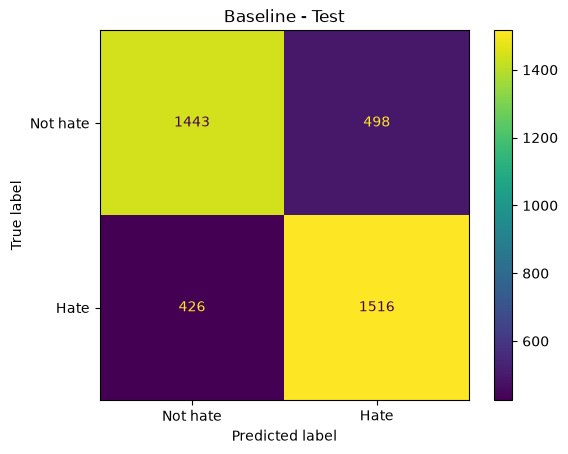

In [42]:
baseline_dev  = evaluate(basemodel, X_val,  y_val,  "Baseline - Validation")
baseline_test = evaluate(basemodel, X_test, y_test, "Baseline - Test")

## **2d: Explanation** (10 marks)

**Question:** Explain your feature representation, baseline model choice, and evaluation results.

Your answer should cover:
* **Feature extraction** - explain which feature extraction or embedding method
you used, how it represents the text, and why it is suitable for your dataset.
* **Why you chose this classifier** - explain why the selected model is suitable for your feature representation and why it provides a reasonable baseline.
* **The metrics you reported in Task 2c** - explain what the selected metrics measure and why using only a single metric, such as accuracy, may be misleading.
* **Your results** - briefly discuss what the obtained scores indicate about the strengths and weaknesses of your baseline model.

Your explanation should be written in your own words and should not exceed **50 words** in length.

```
# YOUR ANSWER HERE



```

---

#  **Section 3**: Improving the Model
### `Total = 30 marks`

Your model works, now make it better. The catch: you must improve the **same model** from Section 2 (e.g. SVM → tuned SVM), not swap in a different classifier.

| Task | What you'll do | Marks |
|---|---|---|
| **3a** | **Improve** your baseline (same model type) | `10` |
| **3b** | **Predict & evaluate** using multiple suitable metrics | `10` |
| **3c** | Explain your **improvement approach** and **the metrics** | `10` |

>  Use the dev set to guide your improvements - hyperparameter tuning, class-imbalance handling, or adjusting your feature-extraction parameters are all fair game.

---

## **3a: Improve your model** (10 marks)

In [ ]:
# YOUR CODE HERE

## **3b: Predict & Evaluate** (10 marks)

In [ ]:
# YOUR CODE HERE

## **3c: Explanation** (10 marks)

**Question:** Explain your improvement approach and your evaluation results.

Your answer should cover:
- **What you changed and why** - the specific improvement(s) you applied in Task 3a, and why you expected them to help, based on what you observed about the baseline in Section 2.
- **The metrics you reported in Task 3b** - how they compare to your baseline's (Task 2): did your improvement actually help, on which metric(s), and by how much? If some metrics improved while others didn't, discuss why that might be.

Your explanation should be written in your own words and should not exceed **50 words** in length.

```
# YOUR ANSWER HERE



```

---

#  That's a wrap!

Thanks for working through this assignment. Double-check your cells run top-to-bottom with saved outputs, then upload to `Canvas` before **01:45 PM, October 9th, 2026**.

See you at the in-lab Q&A and for the grade!

---